# Exercise 1: DCT Smoothing and B-spline Interpolation

This exercise is about smoothing and interpolating medical images using discrete cosine transforms and B-spline basis functions. 

In [ ]:
import numpy as np
np.set_printoptions( suppress=True )

from matplotlib import pyplot as plt

plt.ion()
fileName = 'AbdomenMRCT_0003_0000.nii.gz'

import nibabel as nib

data = nib.load(fileName).get_fdata()
T = np.flipud(data[:, :, 130].T)
N1, N2 = T.shape
fix, ax = plt.subplots(2, 1)
ax[0].imshow(T, cmap='gray')
t_range = [21, 35]
ax[0].plot([N2//2]*2, t_range)  # this indicates the 1D snippet in the 2D image
t = T[t_range[0]:t_range[1]+1, N2//2]
N = t.size
ax[1].stem(t)

## Task 1: Smoothing in 1D
### Task 1a:
Using the first $M=3$ DCT basis functions defined in the book, smooth $\mathbf{t}$ to obtain $\hat{\mathbf{t}}$, and display the result.  
For the middle element of $\hat{\mathbf{t}}$ , illustrate how its value is computed as a weighted sum of the elements in $\mathbf{t}$.  
Also compute this weighted sum explicitly, and verify that it is indeed identical to the middle element of $\hat{\mathbf{t}}$.

In [ ]:
# DCT smoothing with the first M=3 basis functions
#xyz
M = 3
n = np.arange(N)

# Orthonormal DCT-II basis matrix
Phi = np.zeros((N, N))
Phi[:, 0] = 1 / np.sqrt(N)
for k in range(1, N):
    Phi[:, k] = np.sqrt(2 / N) * np.cos(np.pi * (2 * n + 1) * k / (2 * N))

# Keep only the first M basis functions
Phi_M = Phi[:, :M]
weights_M = Phi_M.T @ t
hat_t = Phi_M @ weights_M

# Show the smoothing result
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].stem(t, linefmt='C0-', markerfmt='C0o', basefmt=' ')
ax[0].stem(hat_t, linefmt='C3-', markerfmt='C3o', basefmt=' ')
ax[0].set_title('Task 1a')
ax[0].legend(['original', 'smoothed (M=3)'])
ax[0].grid(True, alpha=0.3)

# Express the middle element as a weighted sum of the original samples
middle = N // 2
kernel_row = Phi_M[middle, :] @ Phi_M.T
explicit_middle = kernel_row @ t

ax[1].stem(kernel_row, linefmt='C0-', markerfmt='C0o', basefmt=' ')
ax[1].axhline(0, color='C3')
ax[1].set_title(f'Kernel for point {middle} (M=3)')
ax[1].legend(['kernel (M=3)'])
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Original middle sample:', float(t[middle]))
print('Smoothed middle sample:', float(hat_t[middle]))
print('Explicit weighted sum:', float(explicit_middle))
print('Absolute difference:', float(np.abs(hat_t[middle] - explicit_middle)))

### Task 1b:
Repeat the previous task, but this time using M=7 basis functions. Discuss the resulting differences.

## Task 2: Smoothing in 2D
### Task 2a:
Using $M=7$ DCT basis functions for both directions, construct the resulting 2D DCT basis functions ($7*7=49$ in total) using the Kronecker product.  
Smooth the image using these basis functions by vectorizing it first, performing the computations in 1D, and un-vectorizing the result back into 2D.
Also display the 49 basis functions as 2D images.

Hints:
- `np.kron()` implements the Kronecker product
- `t = T.reshape(-1, 1, order='F')` will vectorize `T`
- `T = t.reshape(N1, N2, order='F')` will un-vectorize `t`


### Task 2b:
Repeat the smoothing operation, but now exploiting the separability of the
basis functions. Verify that the result obtained this way is identical (up to small 
numerical errors) to the previously obtained result.


## Task 3: Interpolation in 1D
### Task 3a:
Implement a function that evaluates a standard B-spline of order 0, 1 and 3 at arbitrary locations.  
Use this function to draw the B-splines of these orders over the interval $[-3, 3]$


In [ ]:
# B-spline function

def b_spline(x, k):

    # Order 0
    if k == 0:
        if -0.5 <= x < 0.5:
            return 1
        elif np.abs(x) == 0.5:
            return 0.5
        else:
            return 0
    # Order 1
    elif k == 1:
        if -1 <= x < 0:
            return x + 1
        elif 0 <= x < 1:
            return -x + 1
        else:
            return 0
    # Order 3
    elif k == 3:
        if np.abs(x) < 1:
            return (2/3-np.abs(x)**2 + 0.5*np.abs(x)**3)
        elif 1 <= np.abs(x) < 2:
            return (1/6)*(2-np.abs(x))**3
        else:
            return 0
    else:
        raise ValueError("Unsupported B-spline order. Only k=0,1,3 are supported.")



In [ ]:
# General B-spline function

def general_b_spline_recursive(x, k):
    """Centered B-spline defined recursively from the zero-order box spline."""
    if k < 0:
        raise ValueError("Order k must be non-negative.")
    
    elif k == 0:
        if -0.5 < x < 0.5:
            return 1.0
        elif np.abs(x) == 0.5:
            return 0.5
        else:
            return 0.0
    else:
        left = (x + (k + 1) / 2) / k * general_b_spline_recursive(x + 0.5, k - 1)
        right = ((k + 1) / 2 - x) / k * general_b_spline_recursive(x - 0.5, k - 1)
        return left + right

In [ ]:
# B-spline interval [-3,3]
dx = 0.01
i = -3
b_0 = []
b_1 = []
b_3 = []

while i < 3:
    b_0.append(b_spline(i, 0))
    b_1.append(b_spline(i, 1))
    b_3.append(b_spline(i, 3))
    i += dx

# Plot B-spline of order 0
plt.figure(figsize=(8, 5))
plt.plot(b_0, label='B(x, 0)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 0')
plt.show()

# Plot B-spline of order 1
plt.figure(figsize=(8, 5))
plt.plot(b_1, label='B(x, 1)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 1')
plt.show()

# Plot B-spline of order 3
plt.figure(figsize=(8, 5))
plt.plot(b_3, label='B(x, 3)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 3')
plt.show()

### Task 3b:
Interpolate $\mathbf{t}$ at the non-integer locations `x_interp` defined below, using B-splines of order 0, 1 and 3.
For each order, plot the resulting curve along with the original points in $\mathbf{t}$.

In [ ]:
x_interp = np.linspace(0, N, 1000)

# Create the phi matrix for B-spline of order 0
phi_0 = np.zeros((N, N))

# Fill the phi matrix
for i in range(N):
    for j in range(N):
        phi_0[i][j] = b_spline(i - j, 0)

# Compute weights for B-spline of order 0
weights_0 = np.linalg.inv(phi_0) @ t
y_0 = np.zeros_like(x_interp)

# Compute the signal approximation using B-spline of order 0
for i in range(1000):
    for j in range(N):
        y_0[i] += weights_0[j] * b_spline(x_interp[i] - j, 0)

# Plot signal approximation using B-spline of order 0
plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_0, label='B(x, 0)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 0')
plt.show()


# Same process for B-spline of order 1
phi_1 = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        phi_1[i][j] = b_spline(i - j, 1)

weights_1 = np.linalg.inv(phi_1) @ t
y_1 = np.zeros_like(x_interp)
for i in range(1000):
    for j in range(N):
        y_1[i] += weights_1[j] * b_spline(x_interp[i] - j, 1)

# Plot signal approximation using B-spline of order 1
plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_1, label='B(x, 1)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 1')
plt.show()


# Same process for B-spline of order 3
phi_3 = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        phi_3[i][j] = b_spline(i - j, 3)

weights_3 = np.linalg.inv(phi_3) @ t
y_3 = np.zeros_like(x_interp)
for i in range(1000):
    for j in range(N):
        y_3[i] += weights_3[j] * b_spline(x_interp[i] - j, 3)

# Plot signal approximation using B-spline of order 3
plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_3, label='B(x, 3)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 3')
plt.show()

## Task 4: Interpolation in 2D
### Task 4a:
Adapt the functions `compute_W()` and `evaluate()` below so that calling `interpolate(T)` will show a 2D cubic interpolation of the blue image grid in the right plot.

Basis x1: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.16666667 0.66666667 0.16666667 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0

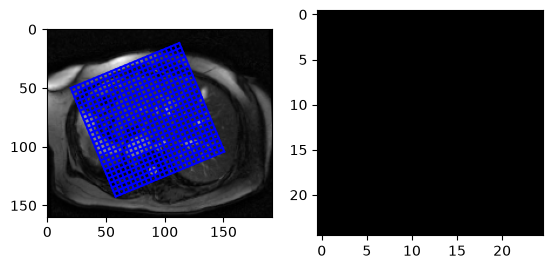

In [ ]:
def compute_W(T):
    """ Computes the weights W of 2D cubic B-splines so that their linear combination 
        will interpolate the 2D image T.
    """  
    # Building phi matrices
    n1, n2 = T.shape
    phi1 = np.zeros((n1, n1))
    phi2 = np.zeros((n2, n2))

    # Fill phi matrices with B-spline values
    for i in range(n1):
        for j in range(n1):
            phi1[i, j] = b_spline(i - j, 3)

    for i in range(n2):
        for j in range(n2):
            phi2[i, j] = b_spline(i - j, 3)

    # Compute weights W
    term1 = np.linalg.inv(phi1.T @ phi1) 
    term2 = phi1.T @ T @ phi2
    term3 = np.linalg.inv(phi2.T @ phi2)

    W = term1 @ term2 @ term3

    return W


def evaluate(W, x1_interp, x2_interp):
    """ Evaluates the linear combination of 2D cubic B-splines with weights W at location
    (x1_interp, x2_interp)
    """
    basis_x1 = np.zeros(W.shape[0])

    for i in range(W.shape[0]):
        basis_x1[i] = b_spline(x1_interp - i, 3)

    basis_x2 = np.zeros(W.shape[1])
    
    for j in range(W.shape[1]):
        basis_x2[j] = b_spline(x2_interp - j, 3)

    print("Basis x1:", basis_x1)
    print("Basis x2:", basis_x2)

    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            value = value + W[i, j] * basis_x1[i] * basis_x2[j]

    return value


def interpolate(T):
    """ Resamples the 2D image T to a different image grid using cubic B-spline interpolation,
        and shows the result.
    """
  
    # define the image grid
    num_points = 25
    alpha = np.pi/8
    orig = (50, 20)
    X, Y = np.meshgrid(np.linspace(0, 100, num_points), 
                       np.linspace(0, 100, num_points), indexing='ij' )
    X1_interp = np.cos(alpha) * X - np.sin(alpha) * Y + orig[0]
    X2_interp = np.sin(alpha) * X + np.cos(alpha) * Y + orig[1]

    # illustrate the location of the image grid
    fig, ax = plt.subplots(1,2)
    ax[0].imshow(T, cmap='gray')
    for i in range(X1_interp.shape[0]):
        ax[0].plot(X2_interp[i,:], X1_interp[i,:], color='b')
    for i in range(X1_interp.shape[1]):
        ax[0].plot(X2_interp[:,i], X1_interp[:,i], color='b')

    # compute the interpolated image
    W = compute_W(T)
    T_interp = np.zeros_like(X1_interp)

    for row in range(X1_interp.shape[0]):
        for col in range(X1_interp.shape[1]):
            x1_interp, x2_interp = X1_interp[row, col], X2_interp[row, col]
            value = evaluate(W, x1_interp, x2_interp)
            T_interp[row, col] = value

    # show the interpolated image
    ax[1].imshow(T_interp, cmap='gray')

interpolate(T)